# Lab: Multiple Linear Regression
*In this lab, we will build a Multiple Linear Regression model using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow. Therefore we will settle with the summaries of hypothetical stage reports.*

---

> ### 📝 1. Business Understanding Report (Summary)
> * **Business Context:** This project continues on the [previously introduced](./04_simple_linear_regression_lab.ipynb) business problem for a hypothetical company, "AdSmart." The company allocates its budget across TV, Radio, and Newspaper advertising but lacks a data-driven way to understand the impact of this spending on sales.
> * **Business Problem:** The marketing team cannot confidently predict how changes in advertising spend will affect sales, making budget allocation inefficient and based on intuition rather than evidence.
> * **Project Goal:** To build a **predictive model** using data on TV, Radio, and Newspaper advertising to create a powerful and complete tool. The ultimate aim is to better explain sales variance and provide a more reliable basis for strategic budget allocation.

---

> ### 📝 2. Analytic Approach Report (Summary)
> *   **Problem Type:** *Supervised Regression*, as the goal is to predict a continuous numerical value (Sales).
> *   **Model Selection:** We will skip trying a baseline simple linear regression model as it was the focus of a [previous lab project](./04_simple_linear_regression_lab.ipynb) and use **Multiple Linear Regression**. This model is the logical *next* step as it allows us to incorporate all available advertising channels (`TV`, `Radio`, `Newspaper`) to create a single, more powerful predictive model.
> *   **Evaluation Metrics:**
>     *   **R-squared & Adjusted R-squared:** To measure how much of the variability in sales our model can explain. Adjusted R-squared is particularly important as it accounts for the number of features, providing a more accurate measure of model fit.
>     *   **Regression Coefficients & their p-values:** To quantify the independent impact of each advertising channel on sales and to determine if those impacts are statistically significant.
>     *   **RMSE (Root Mean Squared Error):** To measure the average magnitude of the prediction errors in the original units of sales (thousands of units), giving us a direct sense of the model's predictive accuracy.  
> 
> ⚠️ **Caution:** For the scope of this lab, no other candicate models are chosen. In a real-world project, it would be prudent to consider and compare multiple algorithms to ensure the best model is selected.

---

> ### 📝 3. Data Requirements Report (Summary)
> *   **Data Source:** The `advertising.csv` dataset, which contains data from 200 different markets.
> *   **Features (Independent Variables):** `TV`, `Radio`, `Newspaper` (spend in thousands of dollars for each).
> *   **Target (Dependent Variable):** `Sales` (in thousands of units).
> *   **Granularity & Privacy:** Each row represents an individual market. The dataset is fully anonymized and contains no sensitive or personally identifiable information (PII).

---

## Stage 4: Data Collection

### 4.1. Initial Data Ingestion and Verification
Let's import the necessary libraries, load the dataset, and perform a quick, high-level check to ensure it is readable and appears correct.

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")

In [4]:
# Load the data
data = pd.read_csv("./data/advertising.csv")

# Take a look at the first 5 rows
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
# Display general information about the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


---

> ### 📝 4. Data Collection Report (Summary)
> * **Collection Process:** The *Advertising Dataset* was downloaded from [Kaggle](https://www.kaggle.com/datasets/ashydv/advertising-dataset) and saved at `./data/advertising.csv`.
> * **Initial Verification:** The dataset loads successfully. The number of rows matches the expected count of 200 markets. The `Unnamed: 0` column appears to be an index and can be dropped. The other columns (`TV`, `Radio`, `Newspaper`, `Sales`) are present as expected. There are no missing values in any of the columns, and the data types seem appropriate.

---

## Stage 5: Data Understanding

### 5.1. Initial Data Shaping
Before diving into Exploratory Data Analysis (EDA), let's perform a first pass of cleaning and shaping to handle obvious errors and inconsistencies that would otherwise break visualizations or skew summary statistics.

In [6]:
# Drop columns we know we won't be using
sales_df = data.drop(columns=['Unnamed: 0'])

# Convert column names to lower case
sales_df.columns = [col.lower() for col in sales_df.columns]

# Check the number of duplicated rows
print(f"There are {sales_df.duplicated().sum()} duplicated rows in the dataset.")

There are 0 duplicated rows in the dataset.


In [7]:
# Check the data types of the columns
print(sales_df.dtypes)

tv           float64
radio        float64
newspaper    float64
sales        float64
dtype: object


### 5.2. Descriptive Statistics
Let's compute summary statistics to get a high-level quantitative overview of the dataset.

In [8]:
# Generate the descriptive statistics
stats_df = sales_df.describe().T

# Calculate and add the Coefficient of Variation (CV) column
stats_df['cv'] = stats_df['std'] / stats_df['mean']

# Display the result
stats_df

,count,mean,std,min,25%,50%,75%,max,cv
tv,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4,0.583874
radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6,0.638188
newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0,0.712791
sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0,0.372077


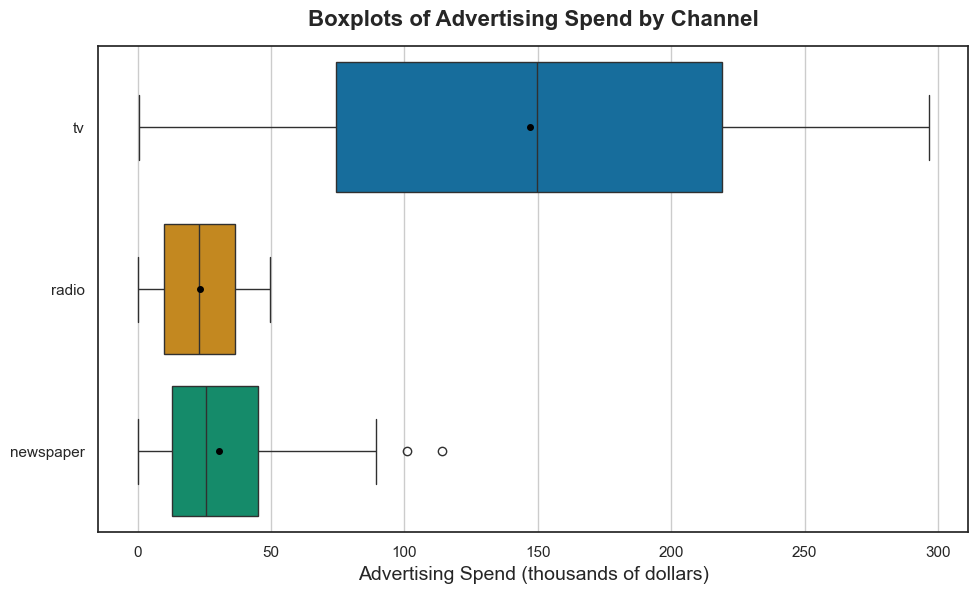

In [9]:
# Visualize the boxplots of independent variables sharing the same units
plt.figure(figsize=(10, 6))
sns.boxplot(data=sales_df[["tv", "radio", "newspaper"]], orient="h", showmeans=True, meanprops={
    "marker":"o",
    "markerfacecolor":"black", 
    "markeredgecolor":"black",
    "markersize":"4"
})
plt.title("Boxplots of Advertising Spend by Channel", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Advertising Spend (thousands of dollars)", fontsize=14)
plt.grid(axis="x")
plt.show()

#### 🔍 Key Findings From the Descriptive Statistics
* **TV Advertisement Spend (`tv`):** The mean *($147,043)* and the median (*$149,750*) are close, suggesting a roughly symmetrical distribution. The coefficient of variation (CV) of 0.58 indicates a quite wide spread in spending across different markets.
* **Radio Advertisement Spend (`radio`):** The mean *($23.264)* and the median (*$22,900*) are also close, suggesting a symmetrical distribution. Companies spend significantly less on radio than on TV. The CV of 0.63 indicates an even wider relative spread than TV spending.
* **Newspaper Advertisement Spend (`newspaper`):** The mean *($30.554)* is noticeably higher than the median (*$25,750*), suggesting the data is right-skewed, likely due to a few markets with very high newspaper ad budgets. While spending is slightly higher than on radio, it is still very limited compared to TV. This channel has the highest CV of 0.71, indicating the most inconsistent spending.
* **Sales (`sales`):** The mean *(14.02k units)* is higher than the median (*12.90k units*), which suggests the sales data is also slightly right-skewed. However, the CV of 0.37 is the lowest among all variables, indicating a relatively low and consistent spread in sales across the different markets.

### 5.3. Univariate Analysis
Now, let's analyze individual variables to understand their own distributions and characteristics.

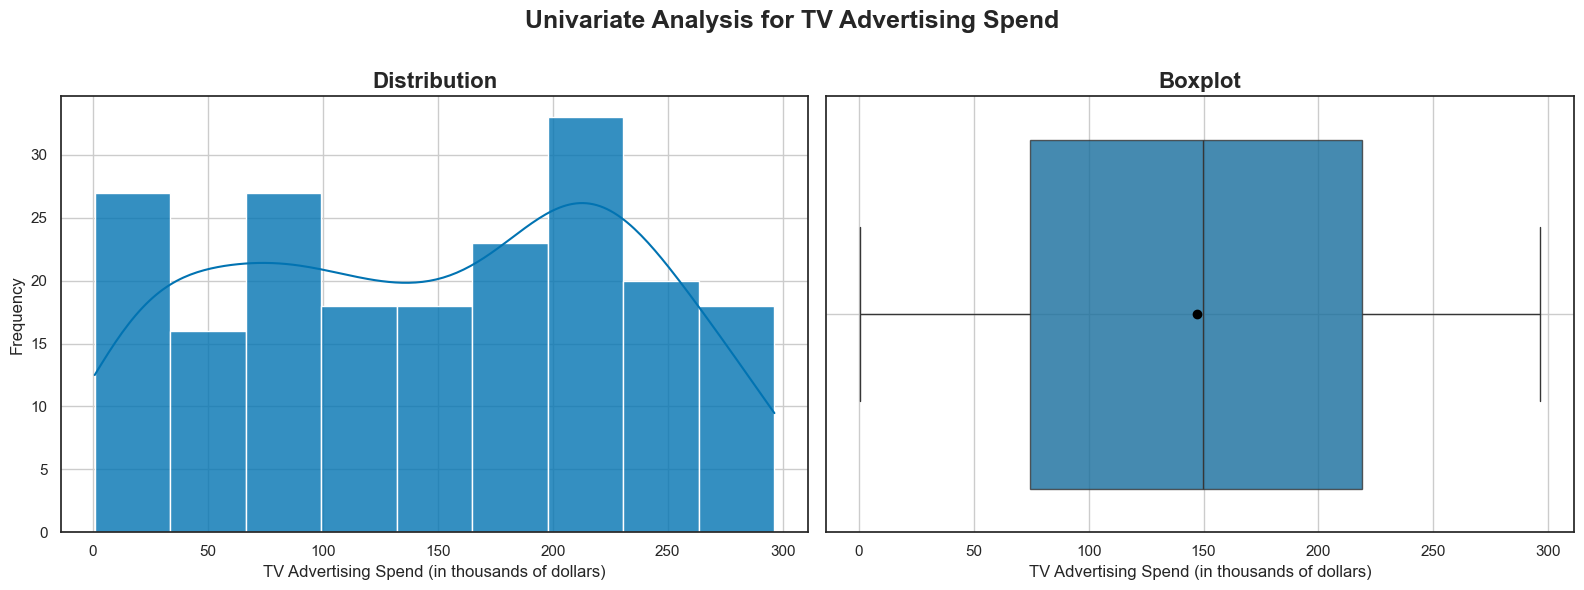

In [10]:
# Univariate Analysis for TV Advertising Spend
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Univariate Analysis for TV Advertising Spend", fontsize=18, fontweight='bold')

# The histogram of TV advertising spend
sns.histplot(sales_df, x="tv", kde=True, ax=ax[0], alpha=0.8)
ax[0].set_title("Distribution", fontsize=16, fontweight='bold')
ax[0].set_xlabel("TV Advertising Spend (in thousands of dollars)")
ax[0].set_ylabel("Frequency")
ax[0].grid(True)

# The boxplot of TV advertising spend
sns.boxplot(sales_df, x="tv", ax=ax[1], boxprops={'alpha':.8}, showmeans=True, meanprops={
    "marker":"o",
    "markerfacecolor":"black", 
    "markeredgecolor":"black",
    "markersize":"6"
})
ax[1].set_title("Boxplot", fontsize=16, fontweight='bold')
ax[1].set_xlabel("TV Advertising Spend (in thousands of dollars)")     
ax[1].grid(True)

plt.tight_layout(rect=(0, 0, 1, 0.975))
plt.show()

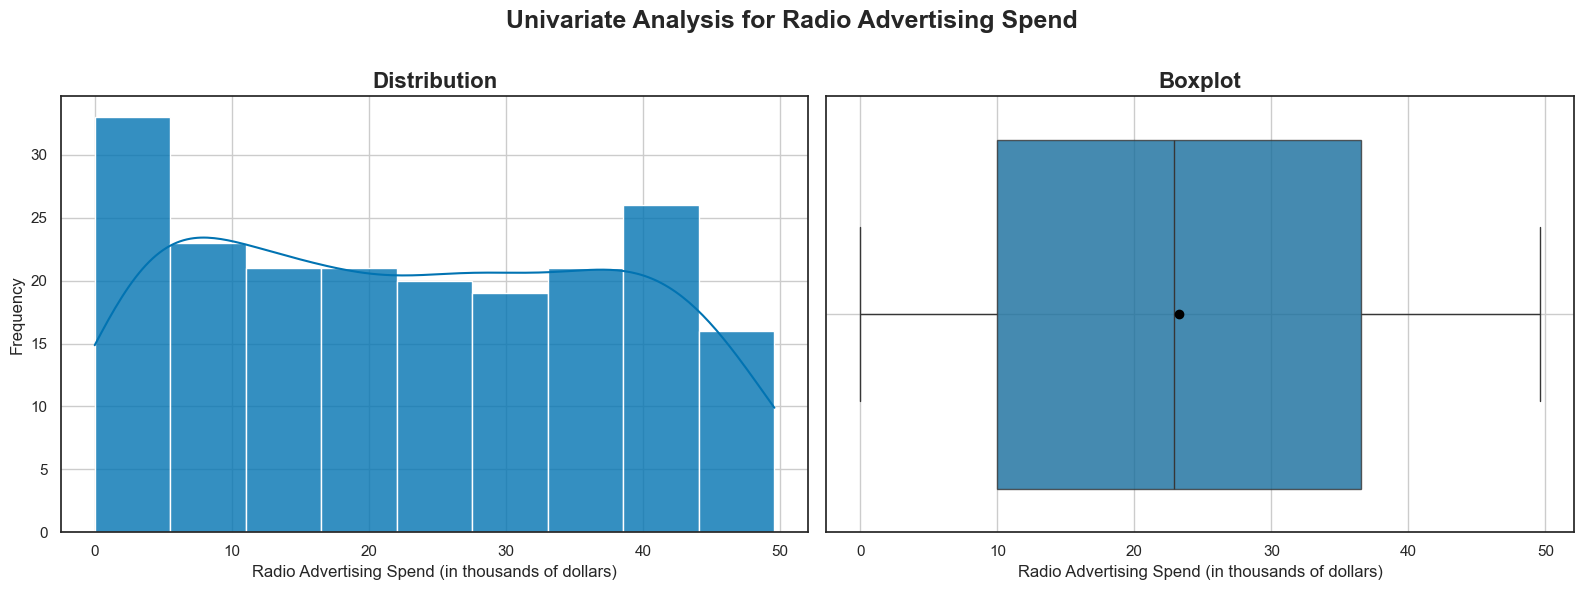

In [11]:
# Univariate Analysis for Radio Advertising Spend
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Univariate Analysis for Radio Advertising Spend", fontsize=18, fontweight='bold')

# The histogram of Radio advertising spend
sns.histplot(sales_df, x="radio", kde=True, ax=ax[0], alpha=0.8)
ax[0].set_title("Distribution", fontsize=16, fontweight='bold')
ax[0].set_xlabel("Radio Advertising Spend (in thousands of dollars)")
ax[0].set_ylabel("Frequency")
ax[0].grid(True)

# The boxplot of Radio advertising spend
sns.boxplot(sales_df, x="radio", ax=ax[1], boxprops={'alpha':.8}, showmeans=True, meanprops={
    "marker":"o",
    "markerfacecolor":"black", 
    "markeredgecolor":"black",
    "markersize":"6"
})
ax[1].set_title("Boxplot", fontsize=16, fontweight='bold')
ax[1].set_xlabel("Radio Advertising Spend (in thousands of dollars)")
ax[1].grid(True)

plt.tight_layout(rect=(0, 0, 1, 0.975))
plt.show()

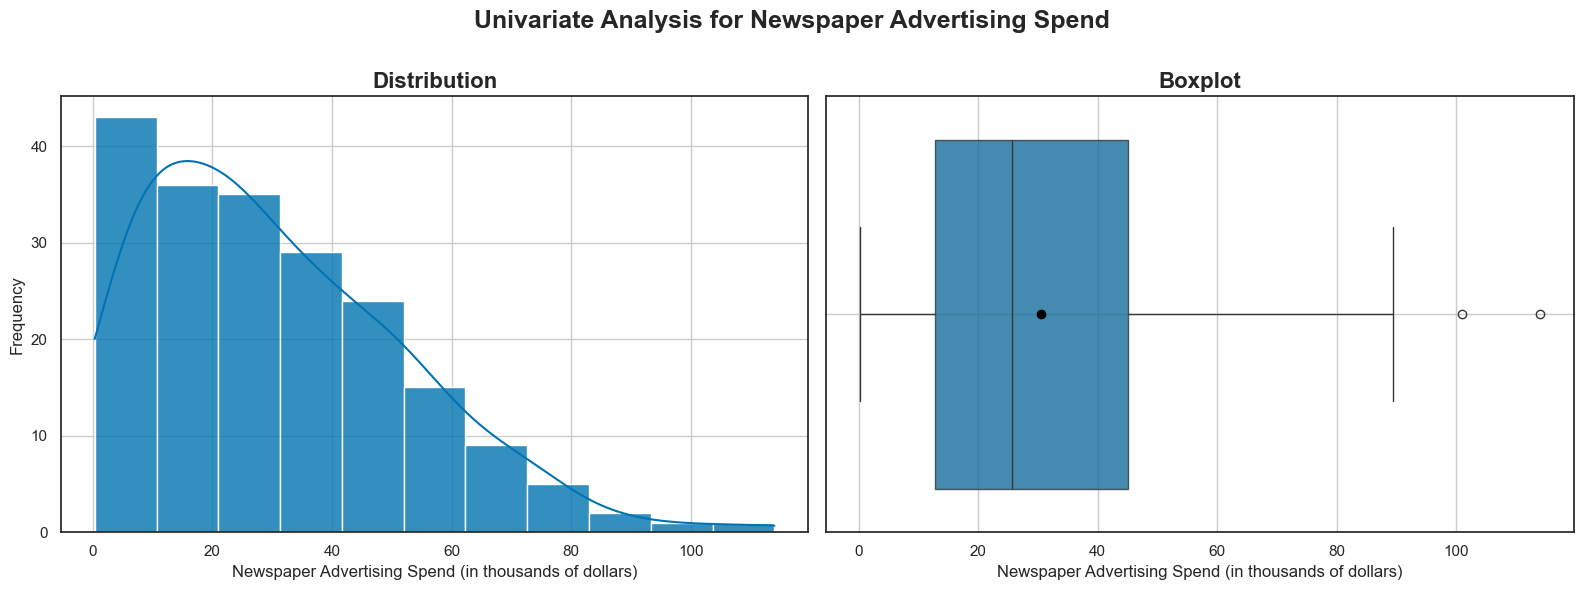

In [12]:
# Univariate Analysis for Newspaper Advertising Spend
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Univariate Analysis for Newspaper Advertising Spend", fontsize=18, fontweight='bold')

# The histogram of Newspaper advertising spend
sns.histplot(sales_df, x="newspaper", kde=True, ax=ax[0], alpha=0.8)
ax[0].set_title("Distribution", fontsize=16, fontweight='bold')
ax[0].set_xlabel("Newspaper Advertising Spend (in thousands of dollars)")
ax[0].set_ylabel("Frequency")
ax[0].grid(True)

# The boxplot of Newspaper advertising spend
sns.boxplot(sales_df, x="newspaper", ax=ax[1], boxprops={'alpha':.8}, showmeans=True, meanprops={
    "marker":"o",
    "markerfacecolor":"black", 
    "markeredgecolor":"black",
    "markersize":"6"
})
ax[1].set_title("Boxplot", fontsize=16, fontweight='bold')
ax[1].set_xlabel("Newspaper Advertising Spend (in thousands of dollars)")
ax[1].grid(True)

plt.tight_layout(rect=(0, 0, 1, 0.975))
plt.show()

In [13]:
# Checking the outliers in newspaper advertising spend
sales_df[sales_df["newspaper"] > 100]

,tv,radio,newspaper,sales
16,67.8,36.6,114.0,12.5
101,296.4,36.3,100.9,23.8


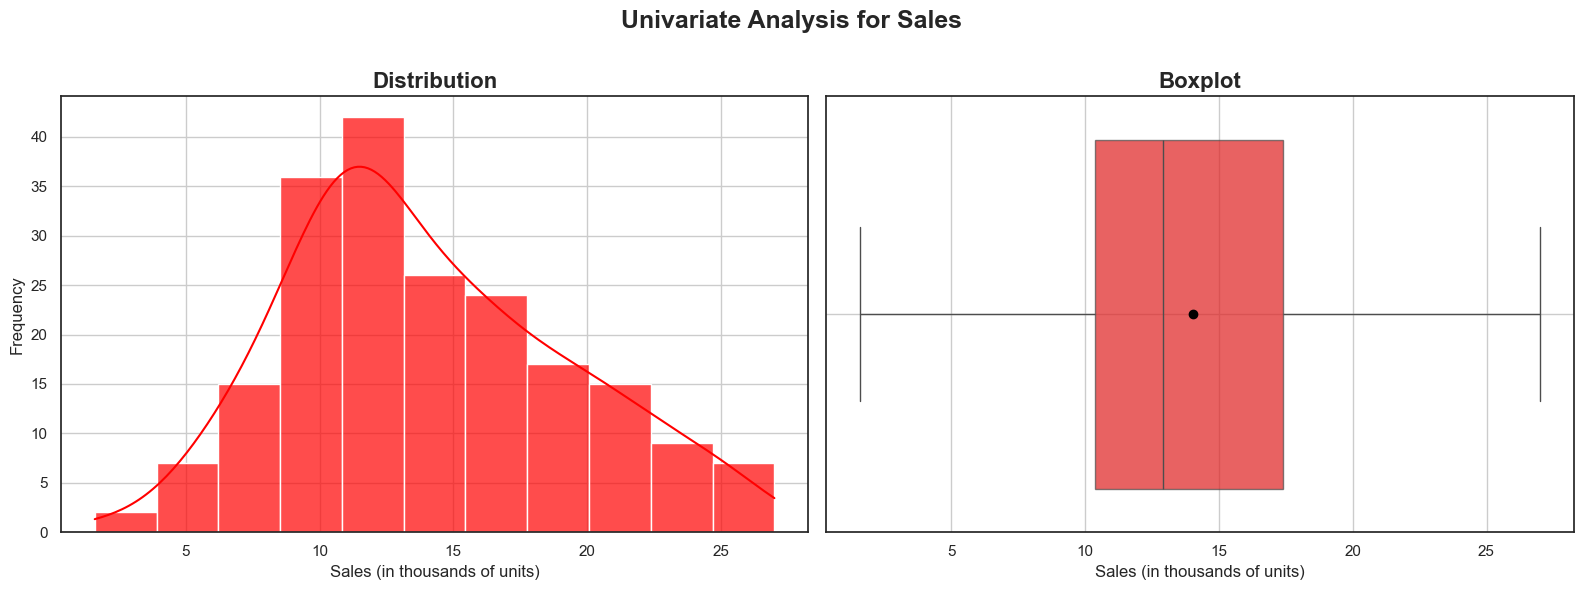

In [14]:
# Univariate Analysis for Sales
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Univariate Analysis for Sales", fontsize=18, fontweight='bold')

# The histogram of Sales
sns.histplot(sales_df, x="sales", kde=True, ax=ax[0], color='red', alpha=0.7)
ax[0].set_title("Distribution", fontsize=16, fontweight='bold')
ax[0].set_xlabel("Sales (in thousands of units)")
ax[0].set_ylabel("Frequency")
ax[0].grid(True)

# The boxplot of Sales
sns.boxplot(sales_df, x="sales", ax=ax[1], color='red', boxprops={'alpha':.7}, showmeans=True, meanprops={
    "marker":"o",
    "markerfacecolor":"black", 
    "markeredgecolor":"black",
    "markersize":"6"
})
ax[1].set_title("Boxplot", fontsize=16, fontweight='bold')
ax[1].set_xlabel("Sales (in thousands of units)")
ax[1].grid(True)

plt.tight_layout(rect=(0, 0, 1, 0.975))
plt.show()

#### 🔍 Key Findings From the Univariate Analysis
* **TV Advertisement Spend (`tv`):** The histogram and the boxplot confirm that the data is roughly symmetrical, without any outliers. 
* **Radio Advertisement Spend (`radio`):** The histogram and the boxplot confirm that the data is roughly symmetrical, without any outliers. 
* **Newspaper Advertisement Spend (`newspaper`):** The histogram and the boxplot shows that the data is highly right-skewed with two outliers in the high-end. One (row 101) was a market with a universally high budget. The other (row 16) was a unique case where newspaper spending was unusually high relative to other channels but resulted in only average sales.
* **Sales (`sales`):** The histogram and the boxplot shows that the data is slightly right-skewed but without any outliers.

### 5.4. Bivariate Analysis 
Now it's time to analyze the pair-wise relationships between our variables. Let's check the correlation matrix and relationship plots.

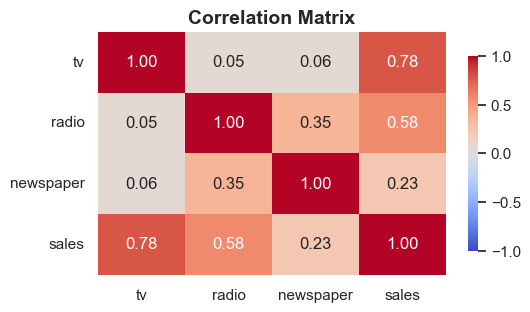

In [15]:
# Correlation Matrix
corr_matrix = sales_df.corr()
plt.figure(figsize=(5, 3))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, cbar_kws={"shrink": .8})
plt.yticks(rotation=0)
plt.title("Correlation Matrix", fontsize=14, fontweight='bold')
plt.show()

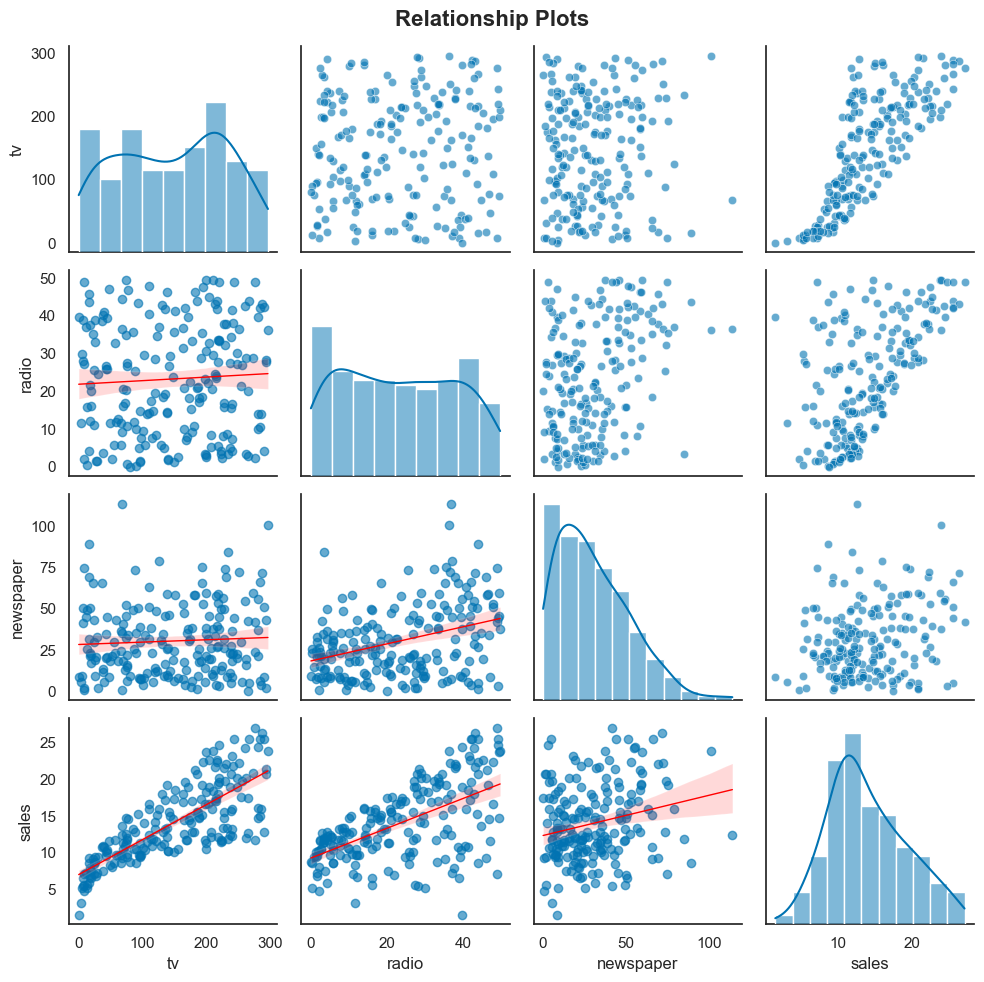

In [16]:
# Create the PairGrid
g = sns.PairGrid(sales_df)

# Map the plots to the grid
g.map_upper(sns.scatterplot, alpha=0.6)
g.map_lower(sns.regplot, scatter_kws={"alpha":0.6}, line_kws={"color":"red", "linewidth":1})
g.map_diag(sns.histplot, kde=True)

g.figure.suptitle("Relationship Plots", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

#### 🔍 Key Findings From the Bivariate Analysis
* **TV and Sales:** There is a strong positive correlation (~0.78) between TV advertising spend and sales, indicating that higher TV ad budgets are associated with higher sales. The regression plot visually confirm this clear positive trend, suggesting a linear relationship, but with slightly increasing variance in higher spend levels.
* **Radio and Sales:** There is a moderate positive correlation (~0.58) between Radio advertising spend and sales, suggesting that Radio ads also contribute positively to sales, but to a lesser extent than TV ads. The regression plot confirms this finding. The variance increases in higher spend levels is more pronounced.
* **Newspaper and Sales:** The correlation between Newspaper advertising spend and sales is weak (~0.23), indicating that Newspaper ads have a minimal impact on sales compared to TV and Radio ads. Regression plot shows that heteroscedasticity is particularly evident in the Newspaper channel.
* **Inter-feature Correlations:** The correlations among the advertising channels themselves are relatively low, suggesting that they provide distinct information and are not redundant.

---

> ### 📝 5. Data Understanding Report (Summary)
>
> **1. Characteristics of Predictor Variables (Advertising Spend):**
> *   **Spending Scale:** There is a clear hierarchy in spending. **TV** advertising receives the largest budget by a significant margin. **Newspaper** and **Radio** budgets are much smaller and are roughly in the same order of magnitude as each other.
> *   **Spending Consistency:** Spending on **TV** and **Radio** is symmetrically distributed, indicating consistent budget allocation strategies. In contrast, **Newspaper** spending is highly right-skewed with two high-end outliers, making it the most inconsistently used advertising channel.
>
> **2. Characteristics of Target Variable (Sales):**
> *   The `sales` data is relatively consistent across markets, exhibiting the lowest relative spread (CV of 0.37) of all variables. The distribution is slightly right-skewed but does not contain significant outliers.
>
> **3. Key Relationships and Implications for Modeling:**
> *   **Predictive Power:** 
>      * **TV spend** has a strong, positive linear relationship with Sales (~0.78 correlation), making it the most promising predictor. 
>      * **Radio** has a moderate positive relationship (~0.58), indicating it is also a valuable predictor. 
>      * **Newspaper** has a very weak relationship (~0.23), suggesting it has minimal predictive power on its own. The `row 16` was a unique case where newspaper spending was unusually high relative to other channels but resulted in only average sales. This data point provides strong evidence of the low return on investment for newspaper advertising and **should be kept** in the dataset to ensure the model learns from this valuable information.
>   
> *   **Modeling Suitability:**
>     *   **(Good):** The low correlation *among* the advertising channels is a positive sign, suggesting that multicollinearity will not be a major issue for a multiple regression model.
>     *   **(Challenge):** The relationship plots reveal signs of **heteroscedasticity** (the spread of sales data increases as ad spend increases). This violates a key assumption of standard linear regression and will need to be addressed during model evaluation.
>
> **Conclusion:** The data is well-suited for a multiple linear regression model. TV and Radio are expected to be significant predictors. Newspaper is unlikely to be significant but should be included in the initial model for statistical verification. The primary challenge during modeling will be to assess and potentially mitigate the effects of heteroscedasticity.

---

## Stage 6: Data Preparation
Since we've already confirmed that the data types of the columns are compatible with the modeling process, there are no outliers scheduled to be removed, and there are no missing values, there's no need for a data cleaning step. 

### 6.1. Final Dataset Split
Let's split the dataset into features (`X`) and target (`y`), and then into training and testing sets.

In [17]:
# Prepare the feature matrix and the target vector
X = sales_df[["tv", "radio", "newspaper"]]
y = sales_df["sales"]

# Final train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


---

> ### 📝 6. Data Preparation Report (Summary)
> * **Data Cleaning:** No data cleaning requirements were identified. The dataset is complete, with no missing values or incorrect data types.
> * **Feature & Target Definition:** The feature matrix `X` was created using the `tv`, `radio`, and `newspaper` columns. The target vector `y` was created using the `sales` column.
> * **Data Splitting:** The dataset was successfully split into training and testing sets using an 80/20 ratio. 80% of the data has been allocated for model training, and the remaining 20% is reserved for model evaluation.

---

## Stage 7: Modeling

### 7.1. Build and Train the Candidate Models
Let's build and train our Multiple Linear Regression model - which is the only candidate model for this lab project.

In [18]:
# Create and train the model
model = LinearRegression().fit(X_train, y_train)


---

> ### 📝 7. Modeling Report (Summary)
> * **Model Creation and Training:** A Multiple Linear Regression model was created using scikit-learn's `LinearRegression` class. The model was trained on the training dataset, which includes all three advertising channels (`TV`, `Radio`, and `Newspaper`) as features.
>  
> ⚠️ **Cautiton:** For the scope of this lab, more advanced techniques like k-fold cross validation were not implemented. It's noted that this would be a standard next step for a real-world project to ensure robust model evaluation and tuning.

---

## Stage 8: Model Evaluation

### 8.1. Performance on the Hold-Out Test Set
Because we have not used cross-validation during training and also have not tried any other candidate models, we will skip the "final model training" step and evaluate the model on the hold-out test set to get an unbiased estimate of its performance.

In [19]:
# Make predictions on the test set
y_pred = model.predict(X_test)

In [20]:
# --- Calculate evaluation metrics ---

# R-squared
r2 = r2_score(y_test, y_pred)
print(f"R-squared on the test set: {r2:.4f}")

# Adjusted R-squared
n = X_test.shape[0]  # number of observations
p = X_test.shape[1]  # number of predictors
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f"Adjusted R-squared on the test set: {adjusted_r2:.4f}")

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
print(f"RMSE on the test set: {rmse:.4f}")

R-squared on the test set: 0.8994
Adjusted R-squared on the test set: 0.8911
RMSE on the test set: 1.7816


In [21]:
# Coefficients and Intercept calculated from the model
coefficients = model.coef_
intercept = model.intercept_

# p-values are calculated on the full dataset using statsmodels
sm_model = sm.OLS.from_formula("sales ~ tv + radio + newspaper", data=sales_df).fit()
p_values = sm_model.pvalues
formatted_p_values = p_values.apply(lambda x: f"{x:.3f}")

# Create a DataFrame to display coefficients, intercept, and p-values
coefs_and_intercept = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_,
    "p-value": formatted_p_values.values[1:], # Exclude intercept p-value
})

# Print the coefficients and their p-values, and the intercept
print(coefs_and_intercept)
print(f"Intercept: {intercept:.4f}")

     Feature  Coefficient p-value
0         tv     0.044730   0.000
1      radio     0.189195   0.000
2  newspaper     0.002761   0.860
Intercept: 2.9791


#### 🔍 Key Findings From The Evaluation Metrics
* **Model Performance:** The model performs well on the hold-out test set, achieving an **R-squared of 0.899**. This indicates that the model explains approximately 90% of the variance in sales. The **Adjusted R-squared is 0.891**, very close to the R-squared, which suggests the model is not overly complex. The **RMSE of 1.78** indicates that, on average, the model's predictions are off by approximately **1,782 units** of sales.
* **Feature Significance and Impact:**
    *   **TV (`tv`):** This is a **statistically significant** predictor (p-value ≈ 0.000). For every additional $1,000 spent on TV ads, sales are predicted to increase by approximately **45 units**.
    *   **Radio (`radio`):** This is the **strongest significant predictor** (p-value ≈ 0.000). For every additional $1,000 spent on Radio ads, sales are predicted to increase by approximately **189 units**.
    *   **Newspaper (`newspaper`):** This predictor is **not statistically significant** (p-value ≈ 0.860). Its coefficient is close to zero, and we can conclude that once TV and Radio spend are accounted for, newspaper advertising has no meaningful impact on sales.

### 8.2. Residual Analysis
To further assess the model's performance, let's analyze the residuals (the differences between the actual and predicted sales values) to check for patterns that might indicate issues with the model.

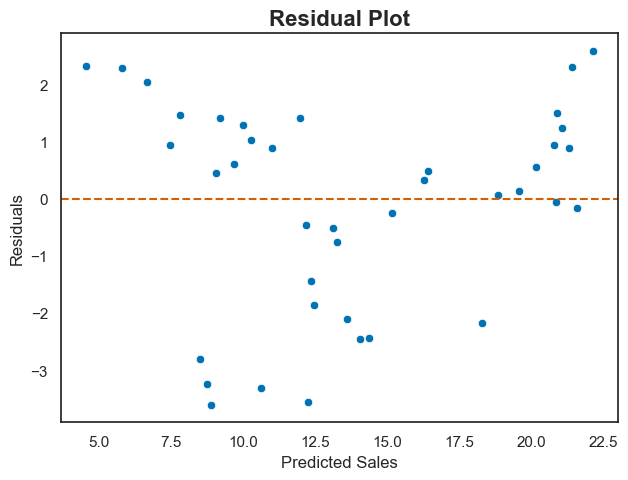

In [22]:
# Calculate and plot residuals
residuals = y_test - y_pred

plt.figure()
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot", fontsize=16, fontweight='bold')
plt.show()

#### 🔍 Key Findings From Residual Analysis
*   **Finding:** The residual plot reveals a subtle but systematic, non-random pattern, suggesting the linear model does not fully capture the underlying relationship in the data.
*   **Detailed Observation:** The residuals exhibit a slight **curvilinear (U-shaped) tendency**:
    *   For markets with **low and high predicted sales**, the residuals **tend to be positive**, meaning the model has a tendency to **under-predict** actual sales.
    *   For markets with **mid-range predicted sales**, the residuals **show a tendency to be negative**, meaning the model tends to **over-predict** actual sales.
*   **Implication:** This pattern signals a potential violation of the **linearity assumption**. The true relationship may have a non-linear component that the current model is too simple to account for.

---

> ### 📝 8. Model Evaluation Report (Summary)
> 
> **Business Impact Analysis:**   
> *   The Multiple Linear Regression model achieved a high R-squared of approximately **0.899**, indicating that about 90% of the variance in sales can be explained by the combined advertising spend.
> *   The model provides clear, actionable insights into channel effectiveness:
>     *   **Radio:** Is the most impactful channel, with every additional $1,000 spent predicting an increase of approximately **189 units**.
>     *   **TV:** Remains a significant driver, with every additional $1,000 spent predicting an increase of approximately **45 units**.
>     *   **Newspaper:** Is shown to be **statistically insignificant**, suggesting its budget could be reallocated.
> *   However, the model's reliability is somewhat undermined by the **subtle but systematic pattern in its residuals**. This indicates the model may be predictably inaccurate for certain segments of the market, which reduces business confidence in its use for precise forecasting.
>
> **Final Model Review and Sign Off:**  
> *   **Decision:** **No-Go for Deployment**
> *   **Justification:** While the model provides powerful insights and has high explanatory power (R² ≈ 0.90), the subtle, non-random pattern in the residuals points to an uncaptured non-linear relationship. Deploying a model with known systematic tendencies for error is not recommended.
> *   **Next Steps:** The immediate next step is to address the potential non-linear relationships. We will **experiment with more complex models, such as Polynomial Regression or including interaction terms**, before making a final deployment decision. This will allow us to build a more accurate and reliable forecasting tool.

---

**Next:** [Polynomial Regression Theory](./08_polynomial_regression_theory.md)